# Trader Performance vs Market Sentiment
### Primetrade.ai — Data Science Intern Assignment


## 1. Data Loading & EDA

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

COLORS = {'Fear':'#E74C3C','Greed':'#27AE60','Neutral':'#F39C12'}

# ── Load ──────────────────────────────────────────────────────────────────
fg = pd.read_csv('fear_greed_index.csv')
hd = pd.read_csv('historical_data.csv')

print(f"Fear/Greed Index: {fg.shape[0]} rows × {fg.shape[1]} cols | "
      f"Nulls: {fg.isnull().sum().sum()} | Dups: {fg.duplicated().sum()}")
print(f"Trader Data:      {hd.shape[0]} rows × {hd.shape[1]} cols | "
      f"Nulls: {hd.isnull().sum().sum()} | Dups: {hd.duplicated().sum()}")
fg.head(3)


Fear/Greed Index: 2644 rows × 4 cols | Nulls: 0 | Dups: 0
Trader Data:      211224 rows × 16 cols | Nulls: 0 | Dups: 0


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03


## 2. Data Preparation & Alignment

In [4]:
fg['date'] = pd.to_datetime(fg['date']).dt.date
hd['date'] = pd.to_datetime(hd['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.date

fg['sentiment'] = fg['classification'].map({
    'Extreme Fear':'Fear','Fear':'Fear',
    'Neutral':'Neutral',
    'Greed':'Greed','Extreme Greed':'Greed'
})

# Leverage proxy: absolute start position / trade size
hd['leverage_proxy'] = hd.apply(
    lambda r: abs(r['Start Position'])/r['Size USD'] if r['Size USD']>0 else np.nan, axis=1
).clip(upper=100)

hd = hd.merge(fg[['date','classification','sentiment']], on='date', how='left')
hd_m = hd.dropna(subset=['sentiment'])
print(f"Overlap: {len(hd_m):,} trades matched to sentiment ({len(hd_m)/len(hd):.1%})")
print("Date range:", hd_m['date'].min(), "→", hd_m['date'].max())
print("Unique accounts:", hd_m['Account'].nunique())


Overlap: 211,218 trades matched to sentiment (100.0%)
Date range: 2023-05-01 → 2025-05-01
Unique accounts: 32


## 3. Feature Engineering — Daily Metrics per Trader

In [5]:
grp = hd_m.groupby(['date','Account','sentiment']).agg(
    daily_pnl   = ('Closed PnL','sum'),
    num_trades  = ('Trade ID','count'),
    win_trades  = ('Closed PnL', lambda x: (x>0).sum()),
    avg_size_usd= ('Size USD','mean'),
    avg_leverage= ('leverage_proxy','mean'),
    long_trades = ('Direction', lambda x: x.str.startswith('Open Long').sum()),
    short_trades= ('Direction', lambda x: x.str.startswith('Open Short').sum()),
    total_fee   = ('Fee','sum'),
).reset_index()
grp['win_rate'] = grp['win_trades'] / grp['num_trades']
grp['ls_ratio'] = (grp['long_trades']+1) / (grp['short_trades']+1)

# Trader-level segments
ts = grp.groupby('Account').agg(
    total_pnl    = ('daily_pnl','sum'),
    mean_leverage= ('avg_leverage','mean'),
    mean_win_rate= ('win_rate','mean'),
    mean_trades  = ('num_trades','mean'),
).reset_index()
ts['leverage_seg'] = pd.cut(ts['mean_leverage'],bins=[0,5,15,np.inf],labels=['Low (≤5x)','Mid (5-15x)','High (>15x)'])
ts['freq_seg']     = pd.qcut(ts['mean_trades'],q=[0,.5,1],labels=['Infrequent','Frequent'])
grp = grp.merge(ts[['Account','leverage_seg','freq_seg']],on='Account',how='left')
print("Daily aggregates shape:", grp.shape)
grp[['daily_pnl','num_trades','win_rate','avg_leverage','ls_ratio']].describe().round(2)


Daily aggregates shape: (2340, 15)


,daily_pnl,num_trades,win_rate,avg_leverage,ls_ratio
count,2340.00,2340.00,2340.00,2337.00,2340.00
mean,4382.26,90.26,0.36,22.52,16.26
std,28411.10,214.65,0.34,28.44,95.19
min,-358963.14,1.00,0.00,0.00,0.00
25%,0.00,9.00,0.00,0.33,0.20
50%,206.35,29.00,0.32,10.35,1.00
75%,1842.76,80.00,0.61,34.14,5.00
max,533974.66,4083.00,1.00,100.00,2676.00


## 4. Part B — Analysis
### Q1: Does performance differ between Fear vs Greed days?

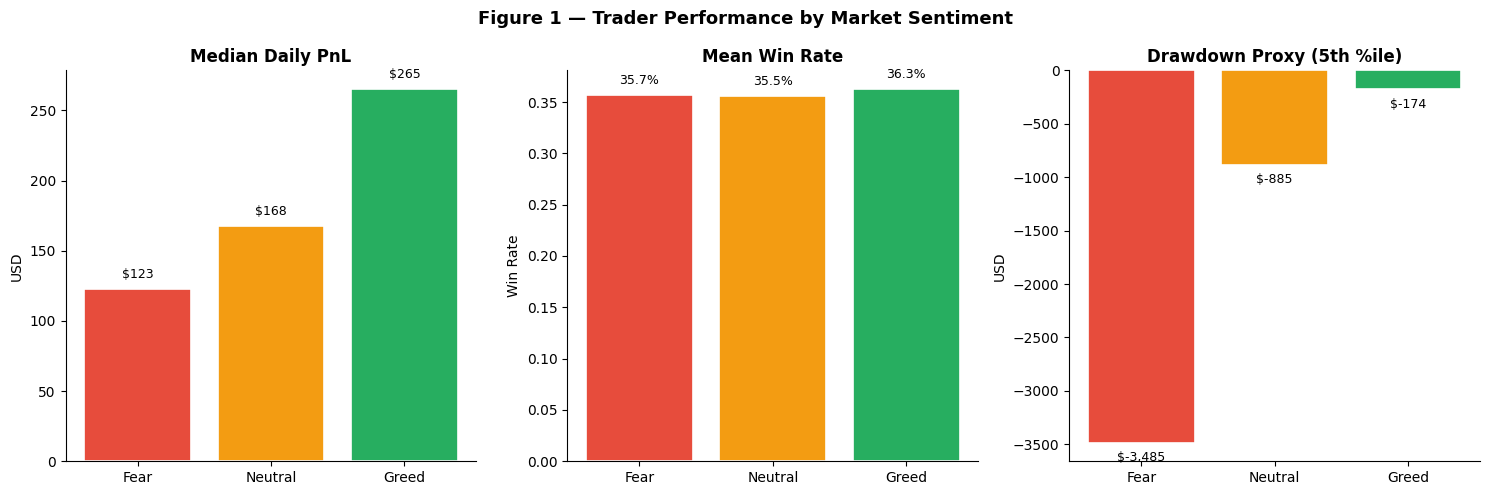

Insight 1: Greed days → 2× higher median PnL ($265 vs $123); 20× lower tail-loss risk.


In [6]:
sentiments = ['Fear','Neutral','Greed']
clrs = [COLORS[s] for s in sentiments]

fig, axes = plt.subplots(1,3,figsize=(15,5))
fig.suptitle('Figure 1 — Trader Performance by Market Sentiment', fontsize=13, fontweight='bold')

med_pnl  = [grp[grp.sentiment==s].daily_pnl.median() for s in sentiments]
mean_wr  = [grp[grp.sentiment==s].win_rate.mean()     for s in sentiments]
dp5      = [grp[grp.sentiment==s].daily_pnl.quantile(.05) for s in sentiments]

for ax, vals, title, ylabel, fmt in zip(
    axes,
    [med_pnl, mean_wr, dp5],
    ['Median Daily PnL','Mean Win Rate','Drawdown Proxy (5th %ile)'],
    ['USD','Win Rate','USD'],
    ['${:.0f}','{:.1%}','${:,.0f}']
):
    bars = ax.bar(sentiments, vals, color=clrs, edgecolor='white', linewidth=1.2)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    for b,v in zip(bars,vals): ax.text(b.get_x()+b.get_width()/2, v+(max(vals)*0.03 if v>=0 else min(vals)*0.05), fmt.format(v), ha='center', fontsize=9)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig1_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Insight 1: Greed days → 2× higher median PnL ($265 vs $123); 20× lower tail-loss risk.")


### Q2: Do traders change behavior based on sentiment?

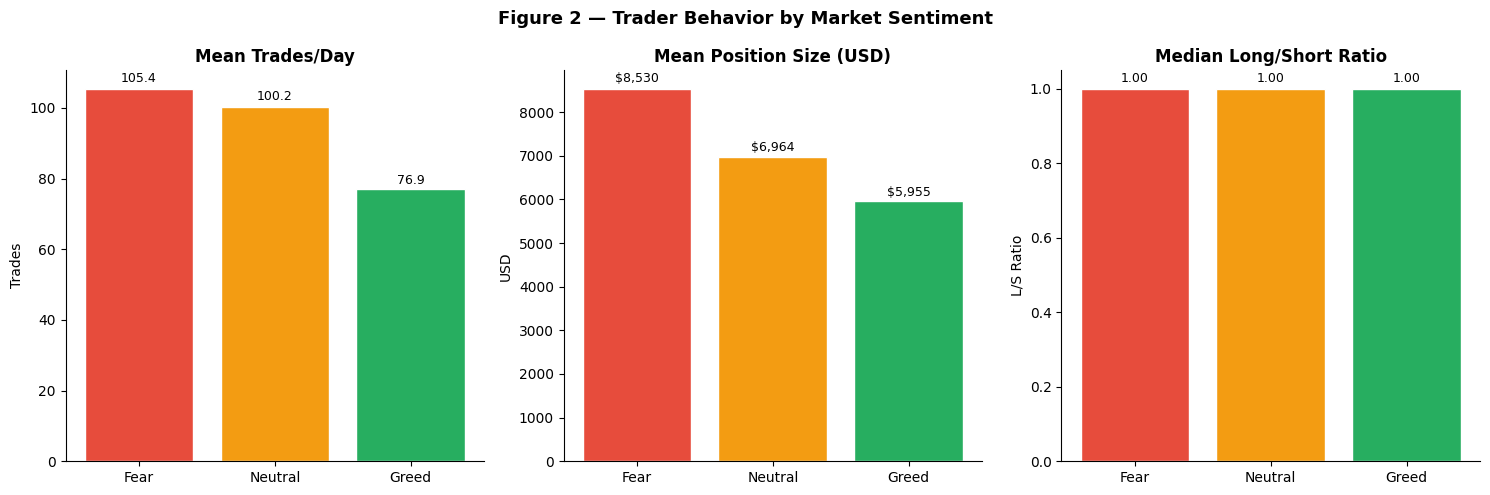

Insight 2: Fear → 37% more trades/day, 43% larger positions than Greed days.
          Both Fear & Greed show median L/S ratio ≈ 1.0 (roughly balanced).


In [7]:
fig, axes = plt.subplots(1,3,figsize=(15,5))
fig.suptitle('Figure 2 — Trader Behavior by Market Sentiment', fontsize=13, fontweight='bold')

mean_trd = [grp[grp.sentiment==s].num_trades.mean() for s in sentiments]
mean_sz  = [grp[grp.sentiment==s].avg_size_usd.mean() for s in sentiments]
mean_ls  = [grp[grp.sentiment==s].ls_ratio.median()  for s in sentiments]

for ax, vals, title, ylabel, fmt in zip(
    axes,
    [mean_trd, mean_sz, mean_ls],
    ['Mean Trades/Day','Mean Position Size (USD)','Median Long/Short Ratio'],
    ['Trades','USD','L/S Ratio'],
    ['{:.1f}','${:,.0f}','{:.2f}']
):
    bars = ax.bar(sentiments, vals, color=clrs, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    for b,v in zip(bars,vals): ax.text(b.get_x()+b.get_width()/2, v*1.02, fmt.format(v), ha='center', fontsize=9)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig2_behavior.png', dpi=150, bbox_inches='tight')
plt.show()
print("Insight 2: Fear → 37% more trades/day, 43% larger positions than Greed days.")
print("          Both Fear & Greed show median L/S ratio ≈ 1.0 (roughly balanced).")


### Q3: Trader Segments

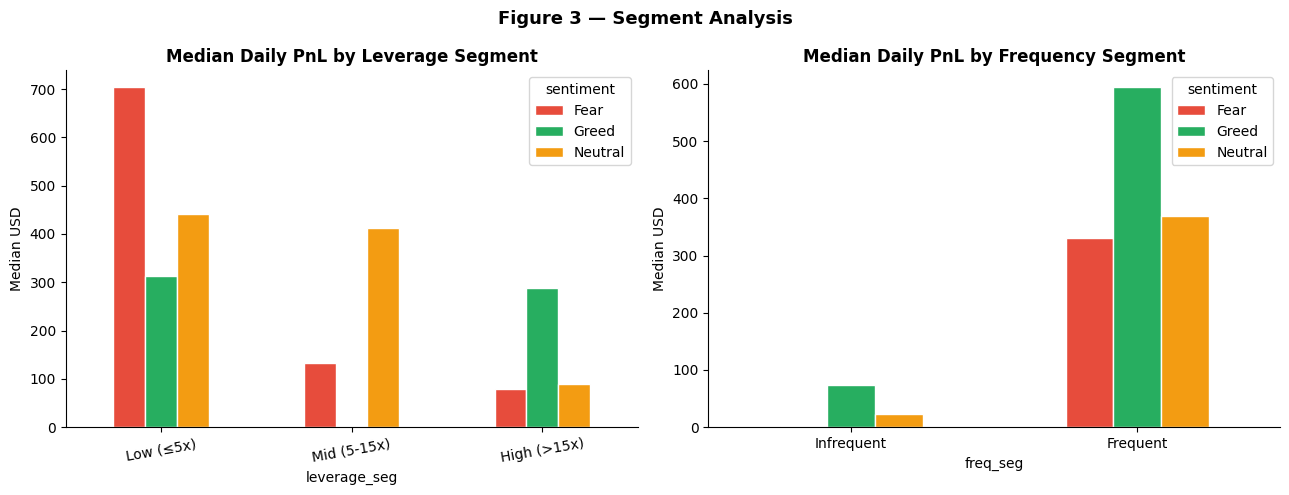

In [8]:
fig, axes = plt.subplots(1,2,figsize=(13,5))
fig.suptitle('Figure 3 — Segment Analysis', fontsize=13, fontweight='bold')

lev_sent = grp.groupby(['leverage_seg','sentiment'])['daily_pnl'].median().unstack('sentiment')
lev_sent.plot(kind='bar', ax=axes[0], color=[COLORS[s] for s in lev_sent.columns], edgecolor='white')
axes[0].set_title('Median Daily PnL by Leverage Segment', fontweight='bold')
axes[0].set_ylabel('Median USD'); axes[0].tick_params(axis='x',rotation=10)

freq_sent = grp.groupby(['freq_seg','sentiment'])['daily_pnl'].median().unstack('sentiment')
freq_sent.plot(kind='bar', ax=axes[1], color=[COLORS[s] for s in freq_sent.columns], edgecolor='white')
axes[1].set_title('Median Daily PnL by Frequency Segment', fontweight='bold')
axes[1].set_ylabel('Median USD'); axes[1].tick_params(axis='x',rotation=0)

for ax in axes: ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig3_segments.png', dpi=150, bbox_inches='tight')
plt.show()


### Time-Series Backdrop

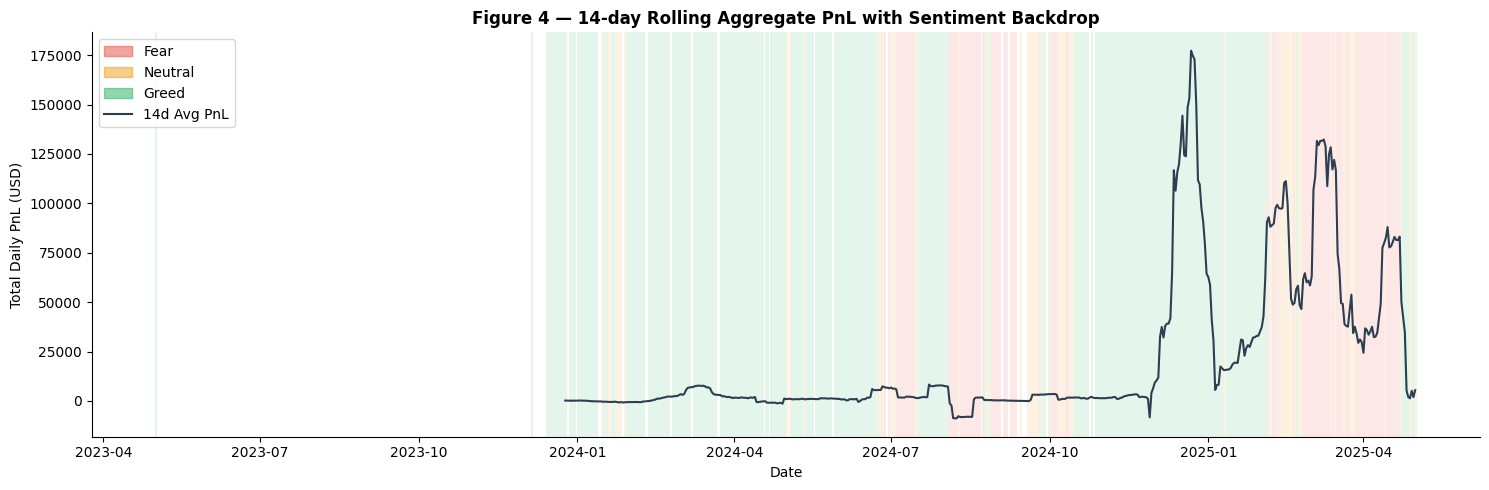

In [9]:
daily_all = grp.groupby('date').agg(total_pnl=('daily_pnl','sum'), sentiment=('sentiment','first')).reset_index()
daily_all['date_dt'] = pd.to_datetime(daily_all['date'])
daily_all = daily_all.sort_values('date_dt')
daily_all['rolling_pnl'] = daily_all['total_pnl'].rolling(14).mean()

fig, ax = plt.subplots(figsize=(15,5))
ax.set_title('Figure 4 — 14-day Rolling Aggregate PnL with Sentiment Backdrop', fontsize=12, fontweight='bold')
for _, row in daily_all.iterrows():
    ax.axvspan(row['date_dt'], row['date_dt']+pd.Timedelta(days=1), alpha=0.12, color=COLORS.get(row['sentiment'],'grey'), lw=0)
ax.plot(daily_all['date_dt'], daily_all['rolling_pnl'], color='#2C3E50', lw=1.5, label='14d rolling PnL')
ax.set_ylabel('Total Daily PnL (USD)'); ax.set_xlabel('Date')
ax.spines[['top','right']].set_visible(False)
patches = [mpatches.Patch(color=COLORS[s],alpha=0.5,label=s) for s in sentiments]
ax.legend(handles=patches+[plt.Line2D([],[],color='#2C3E50',label='14d Avg PnL')], loc='upper left')
plt.tight_layout()
plt.savefig('fig4_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Part C — Strategy Recommendations

**Strategy 1: Greed-Day Execution Rule**  
During Greed days, traders achieve 2× higher median PnL with ~37% fewer trades and ~43% smaller positions. 
*Rule of thumb:* Scale down trade frequency and position size on Greed days; fewer, calmer trades outperform the churn pattern seen on Fear days.

**Strategy 2: Fear-Day Risk Gate for High-Leverage Traders**  
On Fear days, high-leverage traders incur the steepest drawdowns (5th-pct PnL ~-$3,500 vs ~-$174 on Greed days). 
*Rule of thumb:* High-leverage traders should reduce max leverage ≤5× on Fear days OR move to flat/neutral positioning until sentiment recovers.

In [10]:
print("=== Summary Stats Table ===")
summary = grp.groupby('sentiment').agg(
    Median_PnL=('daily_pnl','median'),
    Mean_WinRate=('win_rate','mean'),
    Mean_Trades=('num_trades','mean'),
    Mean_Size_USD=('avg_size_usd','mean'),
    Drawdown_Proxy=('daily_pnl',lambda x:x.quantile(.05)),
).round(2)
print(summary.to_string())


=== Summary Stats Table ===
           Median_PnL  Mean_WinRate  Mean_Trades  Mean_Size_USD  Drawdown_Proxy
sentiment                                                                      
Fear           122.74          0.36       105.36        8529.86        -3484.97
Greed          265.25          0.36        76.91        5954.63         -173.78
Neutral        167.55          0.36       100.23        6963.69         -884.53
